**Importing Libraries**

# New Section

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

**Importing Data Set**

In [ ]:
dataset=pd.read_csv("/content/locf.csv")

In [ ]:
dataset.shape

(303, 14)

In [ ]:
dataset.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0




1.   age
2.   sex (1=male; 0=female)


3.   chest pain type(4 values)
4.   resting blood pressure


5.  serum cholestrol in mg/dl
6.  fasting blood sugar > 120 mg/dl


7.   resting electrocardiographic results (values 0,1,2)
8.   maximum heart rate achieved

9.   exercise induced angina
10.   oldpeak = ST depression induced by exercise relative to rest

11.   the slope of the peak exercise ST segment
12.   number of major vessels (0-3) colored by flourosopy

13.   thal: 3 = normal; 6 = fixed defect; 7 = reversable defect (thallium heart scan or stress test)
14.   target (0 = no heart disease; 1 = heart disease)


In [ ]:
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


**Checking the null values in the Dataset**

In [ ]:
dataset.isnull().sum()#there are no null values in the dataset

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [ ]:
print(dataset.corr()["target"].abs().sort_values(ascending=False))

target      1.000000
ca          0.518909
thal        0.509923
oldpeak     0.504092
thalach     0.415040
cp          0.407075
exang       0.397057
slope       0.377957
sex         0.224469
age         0.222853
restecg     0.183696
trestbps    0.157754
chol        0.070909
fbs         0.059186
Name: target, dtype: float64


**From the above information it shows that most columns are moderately correlated with target, but 'fbs' is very weakly correlated.**

**Finding the corelation between the variables**

In [ ]:
dataset.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.097542,0.104139,0.284946,0.208950,0.118530,0.148868,-0.393806,0.091661,0.203805,0.161770,0.362605,0.127389,0.222853
sex,-0.097542,1.000000,0.010084,-0.064456,-0.199915,0.047862,0.021647,-0.048663,0.146201,0.102173,0.037533,0.093185,0.380936,0.224469
cp,0.104139,0.010084,1.000000,-0.036077,0.072319,-0.039975,0.067505,-0.334422,0.384060,0.202277,0.152050,0.233214,0.265246,0.407075
trestbps,0.284946,-0.064456,-0.036077,1.000000,0.130120,0.175340,0.146560,-0.045351,0.064762,0.189171,0.117382,0.098773,0.133554,0.157754
chol,0.208950,-0.199915,0.072319,0.130120,1.000000,0.009841,0.171043,-0.003432,0.061310,0.046564,-0.004062,0.119000,0.014214,0.070909
fbs,0.118530,0.047862,-0.039975,0.175340,0.009841,1.000000,0.069564,-0.007854,0.025665,0.005747,0.059894,0.145478,0.071358,0.059186
restecg,0.148868,0.021647,0.067505,0.146560,0.171043,0.069564,1.000000,-0.083389,0.084867,0.114133,0.133946,0.128343,0.024531,0.183696
thalach,-0.393806,-0.048663,-0.334422,-0.045351,-0.003432,-0.007854,-0.083389,1.000000,-0.378103,-0.343085,-0.385601,-0.264246,-0.279631,-0.415040
exang,0.091661,0.146201,0.384060,0.064762,0.061310,0.025665,0.084867,-0.378103,1.000000,0.288223,0.257748,0.145570,0.329680,0.397057
oldpeak,0.203805,0.102173,0.202277,0.189171,0.046564,0.005747,0.114133,-0.343085,0.288223,1.000000,0.577537,0.295832,0.341004,0.504092


**Representing the coorelation variables in heatmap**

<Axes: >

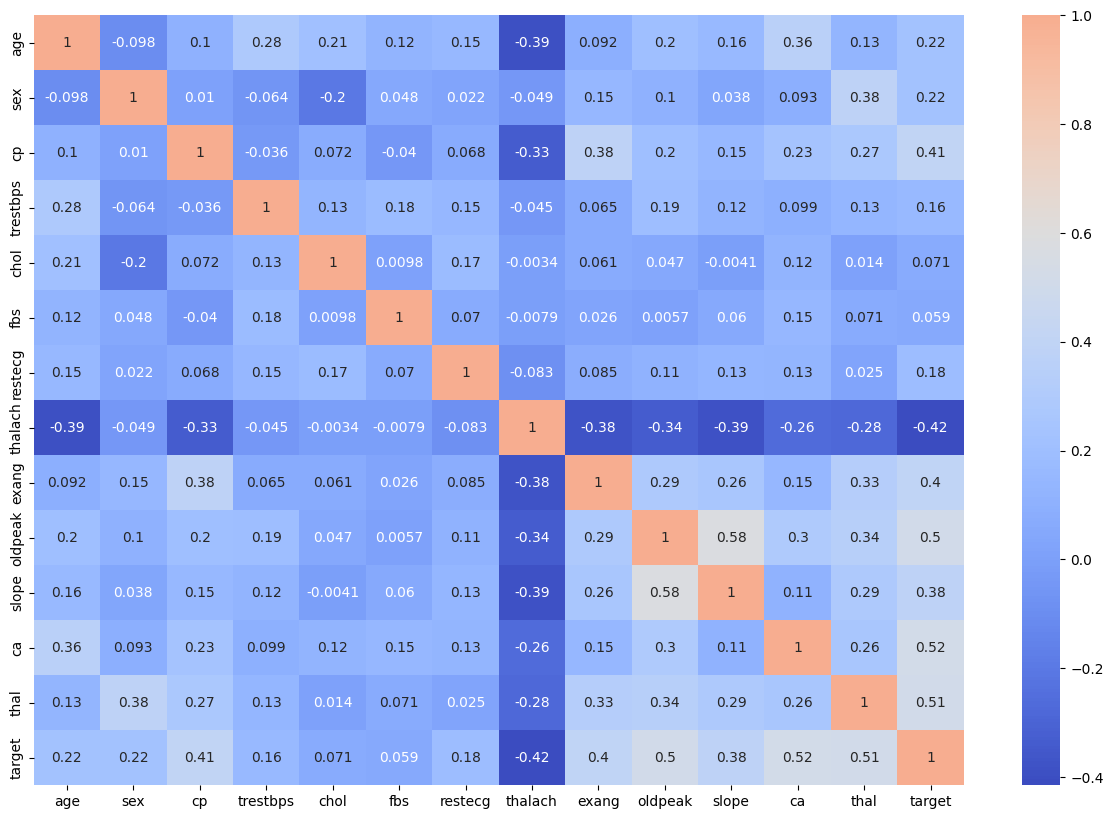

In [ ]:
f, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(dataset.corr(),annot=True,cmap='coolwarm',center=0.6)

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalach'}>],
       [<Axes: title={'center': 'exang'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

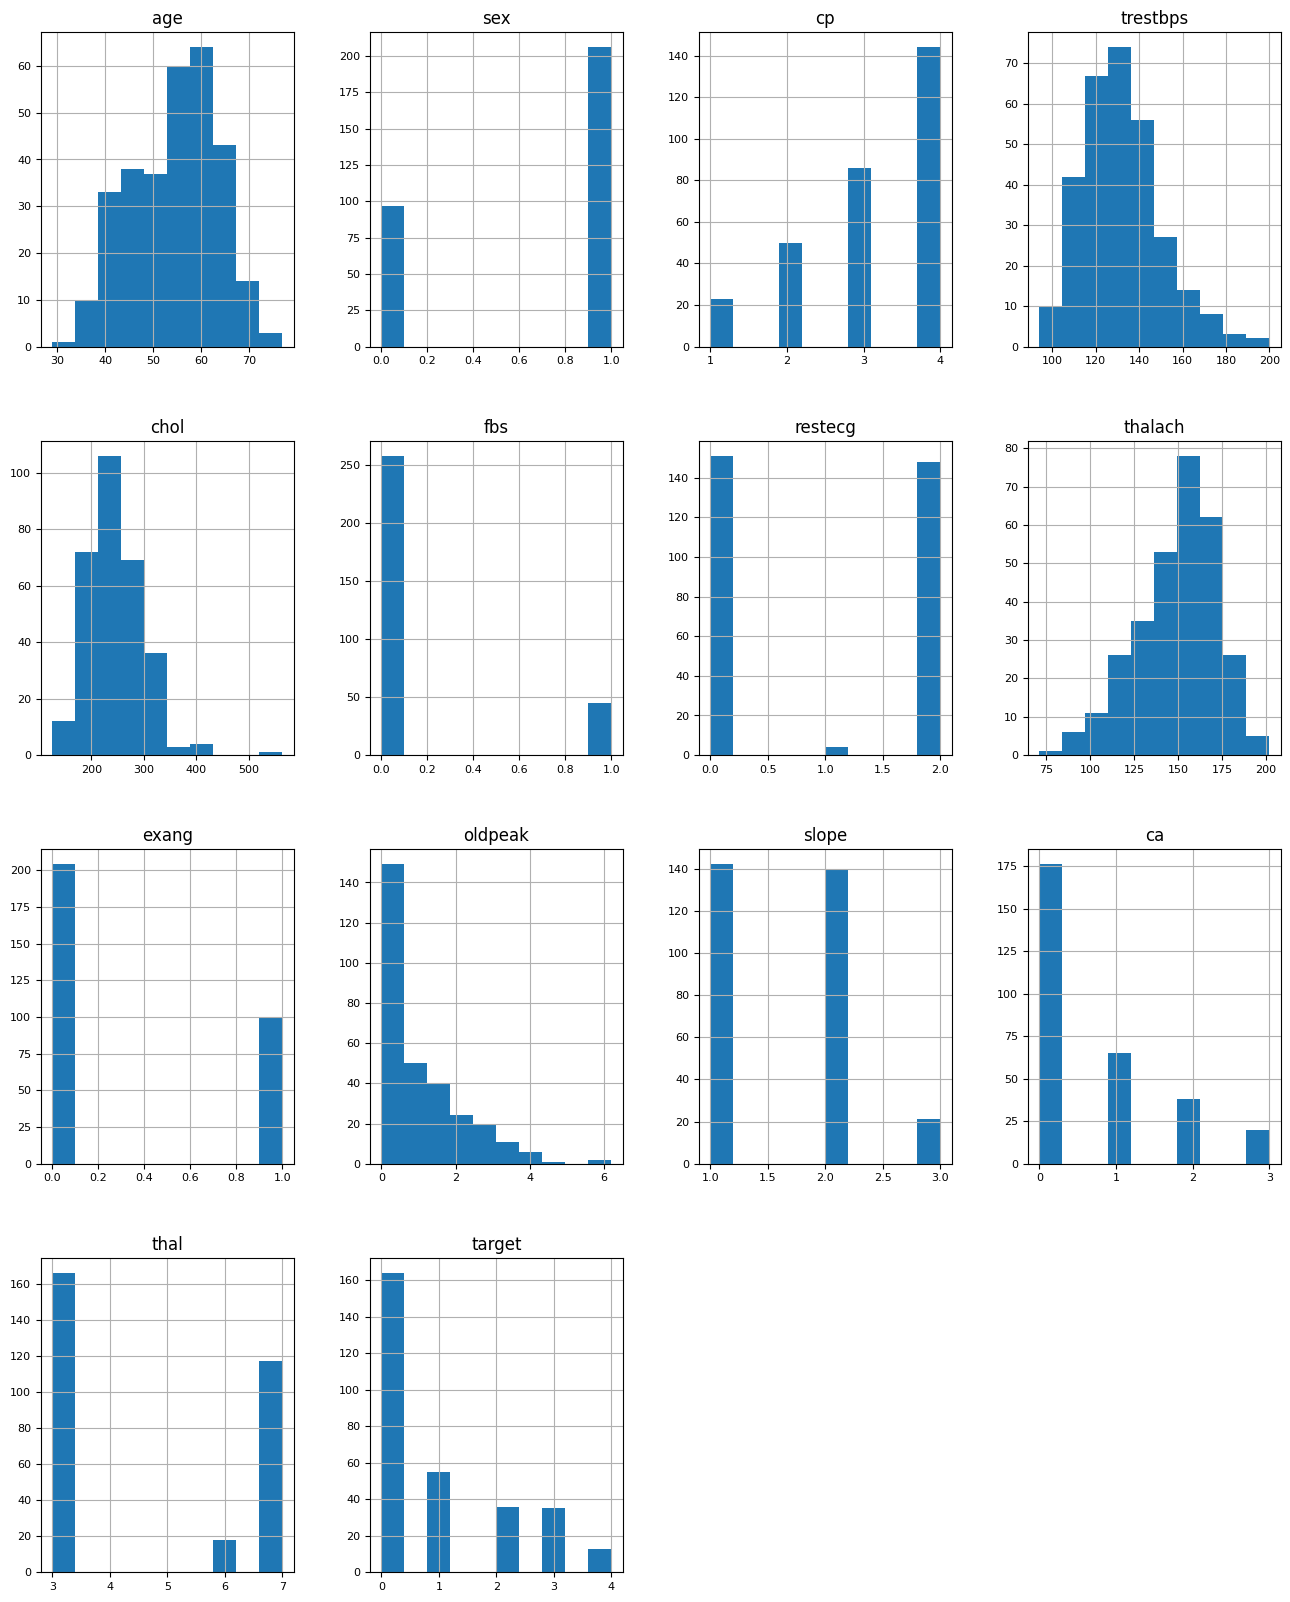

In [ ]:
dataset.hist(figsize=(16, 20), xlabelsize=8, ylabelsize=8)

**Analysing the target variable**

In [ ]:
dataset["target"].unique()

array([0, 2, 1, 3, 4])

Clearly, this is a classification problem, with the target variable having values '0' and '1'

In [ ]:
dataset["target"].describe()

count    303.000000
mean       0.937294
std        1.228536
min        0.000000
25%        0.000000
50%        0.000000
75%        2.000000
max        4.000000
Name: target, dtype: float64

**We will analyse all other features**

**Analysing 'sex' featutre**

In [ ]:
dataset['sex'].value_counts()

1    206
0     97
Name: sex, dtype: int64


*   Sex feature have 2 unique features
*   Sex (1= male; 0=female)

In [ ]:
dataset.groupby(['sex', 'target'])['sex'].count()

sex  target
0    0         72
     1          9
     2          7
     3          7
     4          2
1    0         92
     1         46
     2         29
     3         28
     4         11
Name: sex, dtype: int64

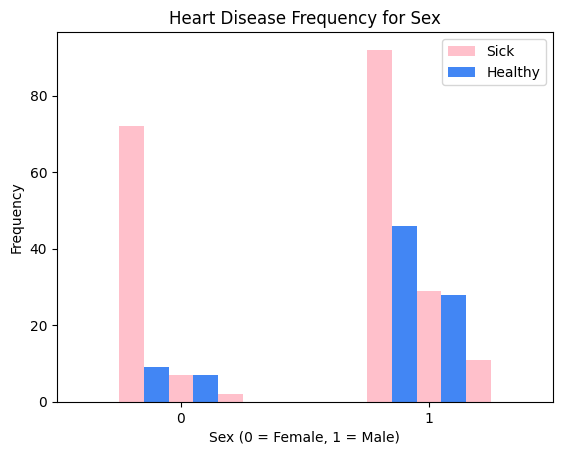

In [ ]:
from google.colab import files
pd.crosstab(dataset.sex,dataset.target).plot(kind="bar",color=['pink','#4286f4' ])
plt.title('Heart Disease Frequency for Sex')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.xticks(rotation=0)
plt.legend(["Sick", "Healthy"])
plt.ylabel('Frequency')
plt.show()
#plt. savefig("gender.png")
#files. download("gender.png")

It look's like many females are suffering more from the heartdisease.

0    164
1     55
2     36
3     35
4     13
Name: target, dtype: int64


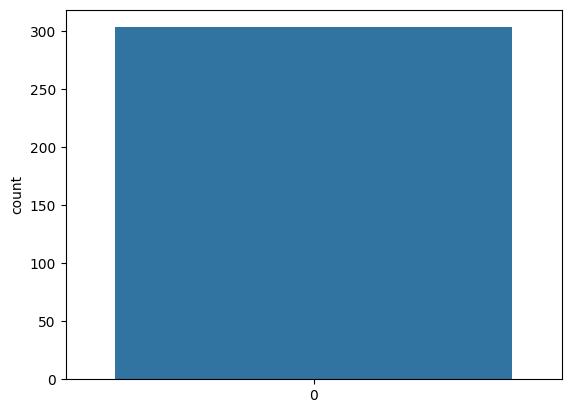

In [ ]:
y = dataset["target"]

sns.countplot(y)


target_temp = dataset.target.value_counts()

print(target_temp)

**Analysing Chest Pain Type Feature**

In [ ]:
dataset["cp"].unique()

array([1, 4, 3, 2])

We can see that chest pain feature have 0 to 3 values.

In [ ]:
import seaborn as sns

# Assuming "dataset" is a pandas DataFrame containing the data
sns.barplot(x="cp", y="target", data=dataset)
# Replace "y" with the name of the column in "dataset" that you want to plot against "cp"

# Add labels and title
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.title("Distribution of Chest Pain Types")

# Show the plot
plt.show()


NameError: ignored

From the above barplot we can say persons with chest pain '0' typical angina are less likely to have heart problems.

**Analysing 'Fasting Blood Sugar' feature fbs**

In [ ]:
dataset['fbs'].unique()

In [ ]:
pd.crosstab(dataset.fbs,dataset.target).plot(kind="bar",color=['#4286f4','#f49242'])
plt.title('Heart Disease Frequency for fbs')
plt.xlabel('FBS- (Fasting Blood Sugar > 120 mg/dl) (1 = true; 0 = false)')
plt.xticks(rotation=0)
plt.legend(["Sick", "Healthy"])
plt.ylabel('Disease or not')
plt.show()

**Analysing the restecg feature**

In [ ]:
dataset['restecg'].unique()

In [ ]:
sns.barplot(dataset["restecg"],y)
#plt. savefig("restecg.png")
#files. download("restecg.png")

From the above information we can say that the people with restecg '1' and '0' are having more chances of heart disease than with restecg '2'

**Analysing the 'exang' feature**

In [ ]:
dataset['exang'].unique()

In [ ]:
sns.barplot(dataset["exang"],y)
#plt. savefig("exang.png")
#files. download("exang.png")

People having exang=1 means Exercise includes angina are having less chances heart problems.(1 = yes; 0 = no)

In [ ]:
dataset['oldpeak'].unique()

In [ ]:
sns.barplot(dataset["oldpeak"],y)
#plt. savefig("oldpeak.png")
#files. download("oldpeak.png")

**Analysing the slope of the peak exercise ST segment**
 (Value 1: upsloping, Value 2: flat, Value 3: downsloping)

In [ ]:
dataset["slope"].unique()

In [ ]:
sns.barplot(dataset["slope"],y)
#plt. savefig("slope.png")
#files. download("slope.png")

from the above information we conclude that slope2 causes much pain than the slope 0 and slope 1.

**Analysing the 'ca' feature** Number of major vessels (0-3) colored by flourosopy

In [ ]:
dataset["ca"].unique()

In [ ]:
sns.countplot(dataset["ca"])
#plt. savefig("ca.png")
#files. download("ca.png")

In [ ]:
sns.barplot(dataset["ca"],y)
#plt. savefig("ca-bar.png")
#files. download("ca-bar.png")

ca=4 has large number of heart patients

**Analysing the 'thal' feature**

In [ ]:
dataset["thal"].unique()

In [ ]:
sns.barplot(dataset["thal"],y)
#plt. savefig("thal.png")
#files. download("thal.png")

In [ ]:
sns.distplot(dataset["thal"])

**Splitting the dataset to Train and Test**

In [ ]:
from sklearn.model_selection import train_test_split

X = dataset.drop(["target","age"],axis=1)
Y = dataset["target"]

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.30
,random_state=0)

In [ ]:
x_train.shape

In [ ]:
x_test.shape

In [ ]:
y_train.shape

In [ ]:
y_test.shape

In [ ]:
y = dataset.target

**Building Models**

**Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()

lr.fit(x_train,y_train)

Y_pred_lr = lr.predict(x_test)


In [ ]:
score_lr = round(accuracy_score(Y_pred_lr,y_test)*100,2)

print("The accuracy score achieved using Logistic Regression is: "+str(score_lr)+" %")

**Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
matrix= confusion_matrix(y_test, Y_pred_lr)

In [ ]:
from google.colab import files
sns.heatmap(matrix,annot = True, fmt = "d")
#plt. savefig("logistic.png")
#files. download("logistic.png")

In [ ]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_test, Y_pred_lr)
print('Confusion Matrix\n')
print(confusion)

In [ ]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, Y_pred_lr)
print("Precision: ",precision)

In [ ]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, Y_pred_lr)
print("Recall is: ",recall)

In [ ]:
print("F1 Score :",(2*precision*recall)/(precision+recall))

**Miss-classification Rate**

In [ ]:
rate_lr = accuracy_score(Y_pred_lr,y_test)
rate = 1-rate_lr
print(rate)

**Specificity**

In [ ]:
ConfusionMatrix =pd.crosstab(y_test, Y_pred_lr)
print(ConfusionMatrix)

In [ ]:
tn=ConfusionMatrix.iloc[0,0]
fp=ConfusionMatrix.iloc[0,1]
fn=ConfusionMatrix.iloc[1,0]
tp=ConfusionMatrix.iloc[1,1]

In [ ]:
specificity_lr = tn/(tn+fp)
print('specificity is:',specificity_lr)

**ROC Area**

In [ ]:
from sklearn import metrics
y_pred_proba = lr.predict_proba(x_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)

In [ ]:
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
auc = metrics.roc_auc_score(y_test, y_pred_proba)
print(auc)

**SVM**

In [ ]:
from sklearn import svm
from sklearn.svm import SVC

sv = svm.SVC(kernel='linear', C=1, gamma=1)

sv.fit(x_train, y_train)

Y_pred_svm = sv.predict(x_test)

In [ ]:
score_svm = round(accuracy_score(Y_pred_svm,y_test)*100,2)

print("The accuracy score achieved using Linear SVM is: "+str(score_svm)+" %")

**Confusion Matrix for SVM**

In [ ]:
matrix= confusion_matrix(y_test, Y_pred_svm)

In [ ]:
from google.colab import files
sns.heatmap(matrix,annot = True, fmt = "d")
#plt. savefig("svmmatrix.png")
#files. download("svmmatrix.png")

In [ ]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, Y_pred_svm)
print("Recall is: ",recall)

In [ ]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, Y_pred_svm)
print("Precision: ",precision)

In [ ]:
print("F1 Score :",(2*precision*recall)/(precision+recall))

**Miss-Classification Rate**

In [ ]:
rate_svm = accuracy_score(Y_pred_svm,y_test)
rate = 1-rate_svm
print(rate)

**Specificity**

In [ ]:
ConfusionMatrix =pd.crosstab(y_test, Y_pred_svm)
print(ConfusionMatrix)

In [ ]:
tn=ConfusionMatrix.iloc[0,0]
fp=ConfusionMatrix.iloc[0,1]
fn=ConfusionMatrix.iloc[1,0]
tp=ConfusionMatrix.iloc[1,1]

In [ ]:
specificity_svm = tn/(tn+fp)
print('specificity is:',specificity_svm)

**ROC Area**

**K Nearest Neighbors**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train,y_train)
Y_pred_knn=knn.predict(x_test)

In [ ]:
score_knn = round(accuracy_score(Y_pred_knn,y_test)*100,2)

print("The accuracy score achieved using KNN is: "+str(score_knn)+" %")

**Confusion Matrix for KNN**

In [ ]:
matrix= confusion_matrix(y_test, Y_pred_knn)
from google.colab import files
sns.heatmap(matrix,annot = True, fmt = "d")
#plt. savefig("Knn.png")
#files. download("Knn.png")

In [ ]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, Y_pred_knn)
print("Recall is: ",recall)

In [ ]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, Y_pred_knn)
print("Precision: ",precision)

In [ ]:
print("F1 Score :",(2*precision*recall)/(precision+recall))

**Miss-Classification Rate**

In [ ]:
rate_knn = accuracy_score(Y_pred_knn,y_test)
rate = 1-rate_knn
print(rate)

**Specificity**

In [ ]:
ConfusionMatrix =pd.crosstab(y_test, Y_pred_knn)
print(ConfusionMatrix)

In [ ]:
tn=ConfusionMatrix.iloc[0,0]
fp=ConfusionMatrix.iloc[0,1]
fn=ConfusionMatrix.iloc[1,0]
tp=ConfusionMatrix.iloc[1,1]

In [ ]:
specificity_knn = tn/(tn+fp)
print('specificity is:',specificity_knn)

**ROC Area**

In [ ]:
from sklearn import metrics
y_pred_proba = knn.predict_proba(x_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)

In [ ]:
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
auc = metrics.roc_auc_score(y_test, y_pred_proba)
print(auc)

**Naive Bayes**

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(x_train,y_train)

Y_pred_nb = nb.predict(x_test)

In [ ]:
score_nb = round(accuracy_score(Y_pred_nb,y_test)*100,2)

print("The accuracy score achieved using Naive Bayes is: "+str(score_nb)+" %")

**Confusion Matrix for Navie bayes**

In [ ]:
matrix= confusion_matrix(y_test, Y_pred_nb)
from google.colab import files
sns.heatmap(matrix,annot = True, fmt = "d")
#plt. savefig("nb.png")
#files. download("nb.png")

In [ ]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, Y_pred_nb)
print("Recall is: ",recall)

In [ ]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, Y_pred_nb)
print("Precision: ",precision)

In [ ]:
print("F1 Score :",(2*precision*recall)/(precision+recall))

**Miss-Classification Rate**

In [ ]:
rate_knn = accuracy_score(Y_pred_nb,y_test)
rate = 1- rate_knn
print(rate)

**Specificity**

In [ ]:
ConfusionMatrix =pd.crosstab(y_test, Y_pred_nb)
print(ConfusionMatrix)

In [ ]:
tn=ConfusionMatrix.iloc[0,0]
fp=ConfusionMatrix.iloc[0,1]
fn=ConfusionMatrix.iloc[1,0]
tp=ConfusionMatrix.iloc[1,1]

In [ ]:
specificity_nb = tn/(tn+fp)
print('specificity is:',specificity_nb)

**ROC Area**

In [ ]:
from sklearn import metrics
y_pred_proba = nb.predict_proba(x_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)

In [ ]:
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
auc = metrics.roc_auc_score(y_test, y_pred_proba)
print(auc)

**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
randfor = RandomForestClassifier(max_depth=5,n_estimators=100, random_state=5)

randfor.fit(x_train, y_train)

y_pred_rf = randfor.predict(x_test)


In [ ]:
score_rf = round(accuracy_score(y_pred_rf,y_test)*100,2)

print("The accuracy score achieved using Random Forest is: "+str(score_rf)+" %")

In [ ]:
matrix= confusion_matrix(y_test, y_pred_rf)
from google.colab import files
sns.heatmap(matrix,annot = True, fmt = "d")
#plt. savefig("rf.png")
#files. download("rf.png")


In [ ]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred_rf)
print("Recall is: ",recall)

In [ ]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred_rf)
print("Precision: ",precision)

In [ ]:
print("F1 Score :",(2*precision*recall)/(precision+recall))

**Miss-Classification Rate**

In [ ]:
rate_rf = accuracy_score(y_pred_rf,y_test)
rate = 1- rate_rf
print(rate)

**Specificity**

In [ ]:
ConfusionMatrix =pd.crosstab(y_test, y_pred_rf)
print(ConfusionMatrix)

In [ ]:
tn=ConfusionMatrix.iloc[0,0]
fp=ConfusionMatrix.iloc[0,1]
fn=ConfusionMatrix.iloc[1,0]
tp=ConfusionMatrix.iloc[1,1]

In [ ]:
specificity_nb = tn/(tn+fp)
print('specificity is:',specificity_nb)

**ROC Area**

In [ ]:
from sklearn import metrics
y_pred_proba = randfor.predict_proba(x_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)

In [ ]:
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
auc = metrics.roc_auc_score(y_test, y_pred_proba)
print(auc)

**Decision Trees**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=4, random_state=0)

dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)

In [ ]:
score_dt = round(accuracy_score(y_pred_dt,y_test)*100,2)

print("The accuracy score achieved using Decision Tree is: "+str(score_dt)+" %")

**ConfusionMatrix DecisionTree**

In [ ]:
matrix= confusion_matrix(y_test, y_pred_dt)
from google.colab import files
sns.heatmap(matrix,annot = True, fmt = "d")
#plt. savefig("dt.png")
#files. download("dt.png")

In [ ]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred_dt)
print("Recall is: ",recall)

In [ ]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred_dt)
print("Precision: ",precision)

In [ ]:
print("F1 Score :",(2*precision*recall)/(precision+recall))

**Miss-Classification Rate**

In [ ]:
rate_dt = accuracy_score(y_pred_dt,y_test)
rate = 1 - rate_dt
print(rate)

**Specificity**

In [ ]:
ConfusionMatrix =pd.crosstab(y_test, y_pred_dt)
print(ConfusionMatrix)

In [ ]:
tn=ConfusionMatrix.iloc[0,0]
fp=ConfusionMatrix.iloc[0,1]
fn=ConfusionMatrix.iloc[1,0]
tp=ConfusionMatrix.iloc[1,1]

In [ ]:
specificity_nb = tn/(tn+fp)
print('specificity is:',specificity_nb)

**ROC Area**

In [ ]:
from sklearn import metrics
y_pred_proba = dt.predict_proba(x_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)

In [ ]:
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
auc = metrics.roc_auc_score(y_test, y_pred_proba)
print(auc)

**K-Fold Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from numpy import mean
from numpy import std
logreg_kf = LogisticRegression()
cv = KFold(n_splits=10, random_state=100, shuffle=True)
scores = cross_val_score(logreg_kf, X, Y, scoring='accuracy', cv=cv, n_jobs=-1)
acc_lr = mean(scores)
print('Accuracy: %.3f' % (mean(scores)))

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from numpy import mean
from numpy import std
svm_kf= svm.SVC(kernel='linear', C=1, gamma=1)
cv = KFold(n_splits=10, random_state=1, shuffle=True)
scores = cross_val_score(svm_kf, X, Y, scoring='accuracy', cv=cv, n_jobs=-1)
print('Accuracy: %.3f' % (mean(scores)))

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from numpy import mean
from numpy import std
knn_kf = KNeighborsClassifier(n_neighbors=7)
cv = KFold(n_splits=10, random_state=1, shuffle=True)
scores = cross_val_score(knn_kf, X, Y, scoring='accuracy', cv=cv, n_jobs=-1)
print('Accuracy: %.3f' % (mean(scores)))

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from numpy import mean
from numpy import std
nb_kf = GaussianNB()
cv = KFold(n_splits=10, random_state=1, shuffle=True)
scores = cross_val_score(nb_kf, X, Y, scoring='accuracy', cv=cv, n_jobs=-1)
print('Accuracy: %.3f' % (mean(scores)))

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from numpy import mean
from numpy import std
Dt_kf = DecisionTreeClassifier(max_depth=4, random_state=0)
cv = KFold(n_splits=10, random_state=1, shuffle=True)
scores = cross_val_score(Dt_kf, X, Y, scoring='accuracy', cv=cv, n_jobs=-1)
print('Accuracy: %.3f' % (mean(scores)))

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from numpy import mean
from numpy import std
rf_kf = RandomForestClassifier(max_depth=5,n_estimators=100, random_state=5)
cv = KFold(n_splits=10, random_state=1, shuffle=True)
scores = cross_val_score(rf_kf, X, Y, scoring='accuracy', cv=cv, n_jobs=-1)
print('Accuracy: %.3f' % (mean(scores)))

In [ ]:
# initialize an empty list
accuracy = []

# list of algorithms names
classifiers = ['KNN','SVM','Logistic Regression', 'Naive Bayes','Decision Tress','Random forest']

# list of algorithms with parameters
models = [KNeighborsClassifier(n_neighbors=7),svm.SVC(kernel='linear', C=1, gamma=1),LogisticRegression(),
        GaussianNB(),DecisionTreeClassifier(max_depth=4, random_state=0),RandomForestClassifier(max_depth=5,n_estimators=100, random_state=5)]

# loop through algorithms and append the score into the list
for i in models:
    model = i
    model.fit(x_train, y_train)
    score = model.score(x_test, y_test)
    accuracy.append(score)

In [ ]:
summary = pd.DataFrame({'accuracy':accuracy}, index=classifiers)
summary